# Netflix Dashboard using Plotly

## Project Objective

The objective of this Netflix Analysis Dashboard is to analyze Netflix content data and identify key trends in content types, genres, ratings, countries, and release patterns to support data-driven business insights.

## Business questions

## Business Questions
1. What is the composition of Netflix's content library between Movies and TV Shows?
2. How Has Netflix's Content Library Evolved Over Time?
3. Which genres dominate Netflix's content library?
4. Which countries have the most diverse range of Netflix content?
5. How does content production differ across countries by content type?
6. What are the dominant content ratings on Netflix, and how do they vary by content type?
7. Which release years show the highest concentration of Netflix titles?
8. What is the typical movie duration, and what does the duration distribution look like?


1. Import necessary libraries.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
df =  pd.read_csv("netflix_titles.csv")

In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
df.shape

(8807, 12)

In [7]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [9]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [10]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [11]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.nunique()

,0
show_id,8807
type,2
title,8807
director,4528
cast,7692
country,748
date_added,1767
release_year,74
rating,17
duration,220


## Data Understanding – Observations

- The dataset contains 8,807 Netflix titles across 12 columns.
- The dataset includes both Movies and TV Shows.
- The Date column is currently stored as an object data type and should be converted to datetime for time-series analysis.
- director, cast, and country contain a significant number of missing values and should be handled carefully during analysis.
- date_added, rating, and duration have only a small number of missing records and can be cleaned without significant data loss.

## Data Cleaning

In [14]:
# convert date column
df["date_added"] = pd.to_datetime(df["date_added"], dayfirst=True, errors="coerce")

In [15]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,datetime64[ns]
release_year,int64
rating,object
duration,object


In [16]:
df["director"].isnull().sum() / len(df) * 100


np.float64(29.908027705234474)

In [17]:
df["director"] = df["director"].fillna("Unknown")

In [18]:
print("Cast:", df["cast"].isnull().sum() / len(df) * 100)
print("Country:", df["country"].isnull().sum() / len(df) * 100)


Cast: 9.367548540933349
Country: 9.435676166685592


In [26]:
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

In [20]:
df['date_added'] = df['date_added'].fillna('Unknown')

In [21]:
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [22]:
df['duration'] = df['duration'].fillna('Unknown')

In [27]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [28]:
df['duration'].head(10)

,duration
0,90 min
1,2 Seasons
2,1 Season
3,1 Season
4,2 Seasons
5,1 Season
6,91 min
7,125 min
8,9 Seasons
9,104 min


In [29]:
df['duration_minutes'] = df['duration'].str.extract(r'(\d+)\s*min')[0]

In [30]:
df['duration_minutes'] = pd.to_numeric(df['duration_minutes'], errors='coerce')

In [31]:
df['seasons'] = df['duration'].str.extract(r'(\d+)\s*Season')[0]

In [32]:
df['seasons'] = pd.to_numeric(df['seasons'], errors='coerce')

In [36]:
df['duration_minutes'].head(10)

,duration_minutes
0,90.0
1,NaN
2,NaN
3,NaN
4,NaN
5,NaN
6,91.0
7,125.0
8,NaN
9,104.0


In [37]:
df['seasons'].head(10)

,seasons
0,NaN
1,2.0
2,1.0
3,1.0
4,2.0
5,1.0
6,NaN
7,NaN
8,9.0
9,NaN


## Data Cleaning – Observations
- Missing values identified in director, cast, country, date_added, rating, and duration.
- Missing values in director, cast, and country are replaced with "Unknown" to retain all records.
- Missing values in date_added are handled by replacing them with "Unknown" or treating them appropriately during date analysis.
- Missing values in rating are replaced with the most frequent rating (mode).
- Missing values in duration are replaced with "Unknown".
- date_added is converted from object to datetime format for accurate time-based analysis.
- duration is separated into meaningful components such as duration in minutes for Movies and number of seasons for TV Shows
- Duplicate records are checked and removed
- The cleaned dataset is then validated to ensure there are no unexpected missing values or duplicate records before dashboard development.

# Exploratory Data Analysis (EDA)

## 1. Composition of Movies vs TV Shows

In [38]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


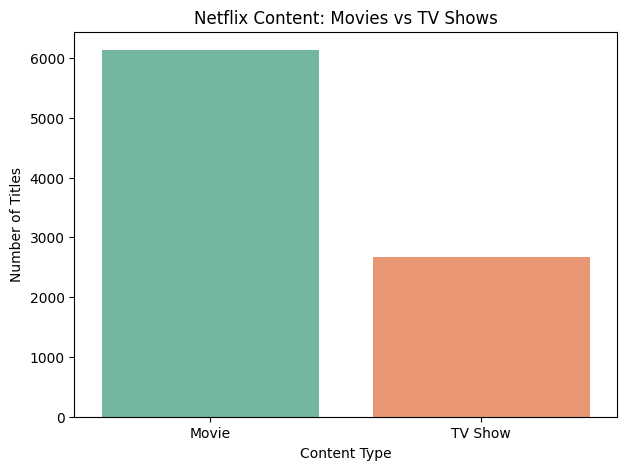

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='type', hue='type', palette='Set2', legend=False)

plt.title('Netflix Content: Movies vs TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.show()

## 2. Movies vs TV Shows by Release Year

In [43]:
content_by_year = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)

content_by_year.tail()


type,Movie,TV Show
release_year,,
2017,767,265
2018,767,380
2019,633,397
2020,517,436
2021,277,315


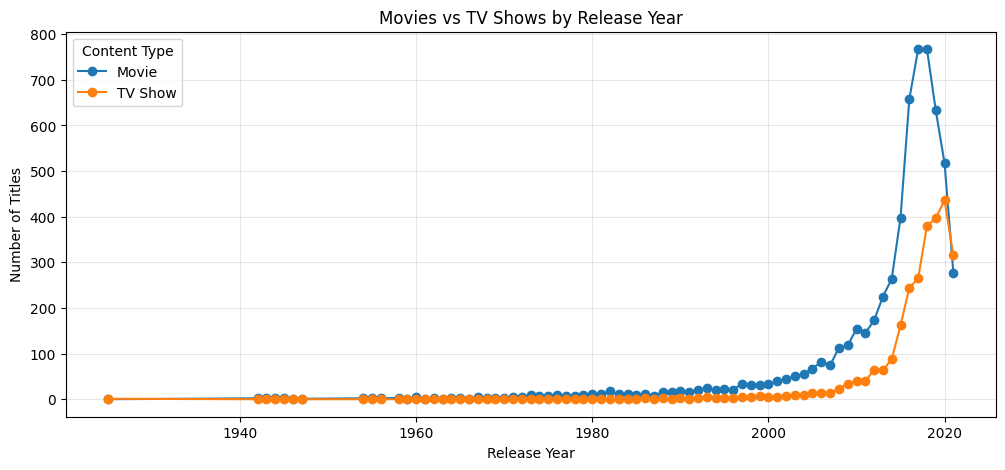

In [44]:
content_by_year.plot(
    figsize=(12, 5),
    marker='o'
)

plt.title('Movies vs TV Shows by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend(title='Content Type')
plt.grid(alpha=0.3)

plt.show()


## 3. Which Genres Dominate Netflix's Content Library?

In [45]:
genres = df['listed_in'].str.split(', ').explode()

top_10_genres = genres.value_counts().head(10)

top_10_genres


,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


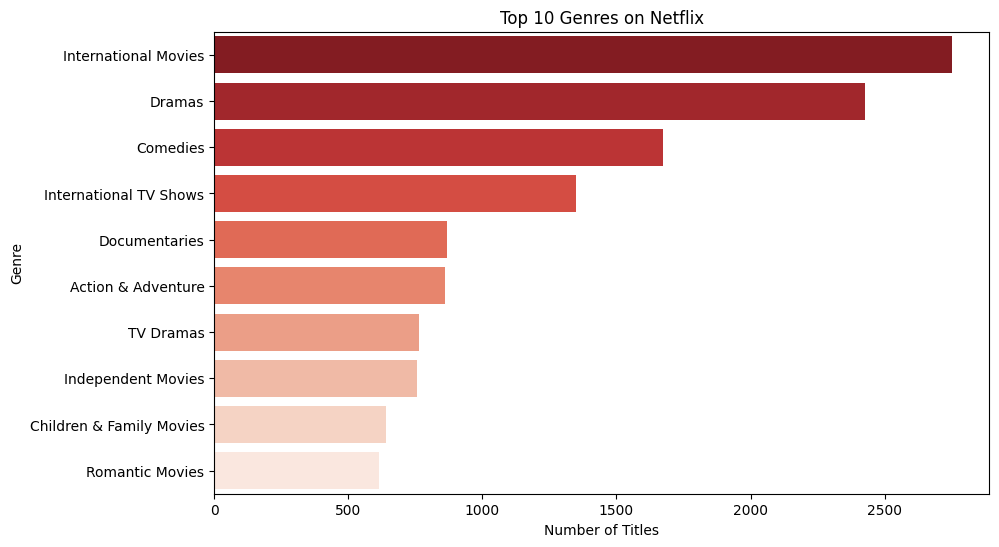

In [46]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_genres.values,
    y=top_10_genres.index,
    hue=top_10_genres.index,
    palette='Reds_r',
    legend=False
)

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.show()


## 4. Which countries have the most diverse range of Netflix content?

In [49]:
country_genre = df.assign(
    country=df['country'].str.split(', ')
).explode('country')

country_genre = country_genre.assign(
    genre=country_genre['listed_in'].str.split(', ')
).explode('genre')


In [50]:
country_diversity = (
    country_genre.groupby('country')['genre']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

country_diversity


,genre
country,
Unknown,42
United States,42
Canada,37
United Kingdom,37
Australia,36
Japan,35
India,35
France,35
Spain,32


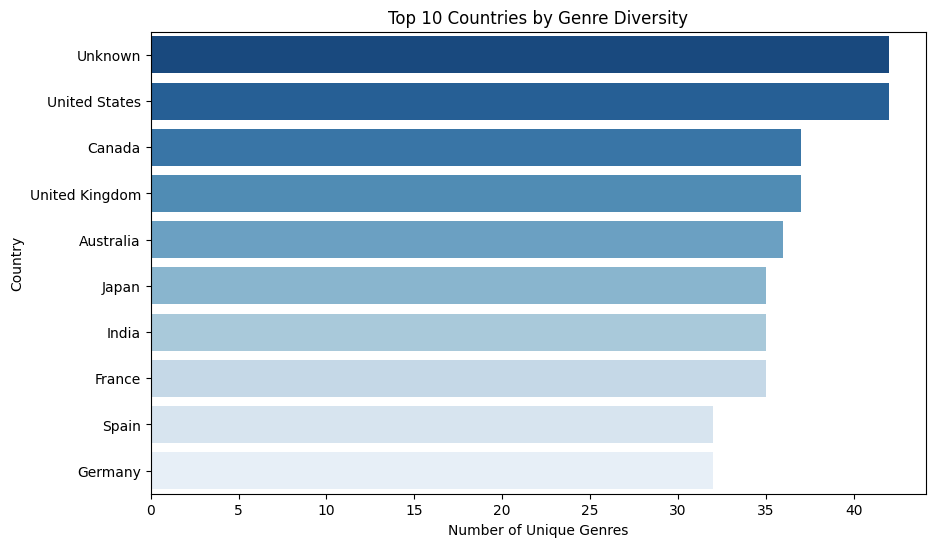

In [51]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=country_diversity.values,
    y=country_diversity.index,
    hue=country_diversity.index,
    palette='Blues_r',
    legend=False
)

plt.title('Top 10 Countries by Genre Diversity')
plt.xlabel('Number of Unique Genres')
plt.ylabel('Country')

plt.show()


## 5. Content Production by Country and Type

In [52]:
country_type = df.assign(
    country=df['country'].str.split(', ')
).explode('country')


In [53]:
country_type_count = pd.crosstab(
    country_type['country'],
    country_type['type']
)

top_countries = (
    country_type['country']
    .value_counts()
    .head(10)
    .index
)

country_type_top = country_type_count.loc[top_countries]

country_type_top


type,Movie,TV Show
country,,
United States,2751,938
India,962,84
Unknown,440,391
United Kingdom,532,272
Canada,319,126
France,303,90
Japan,119,199
Spain,171,61
South Korea,61,170


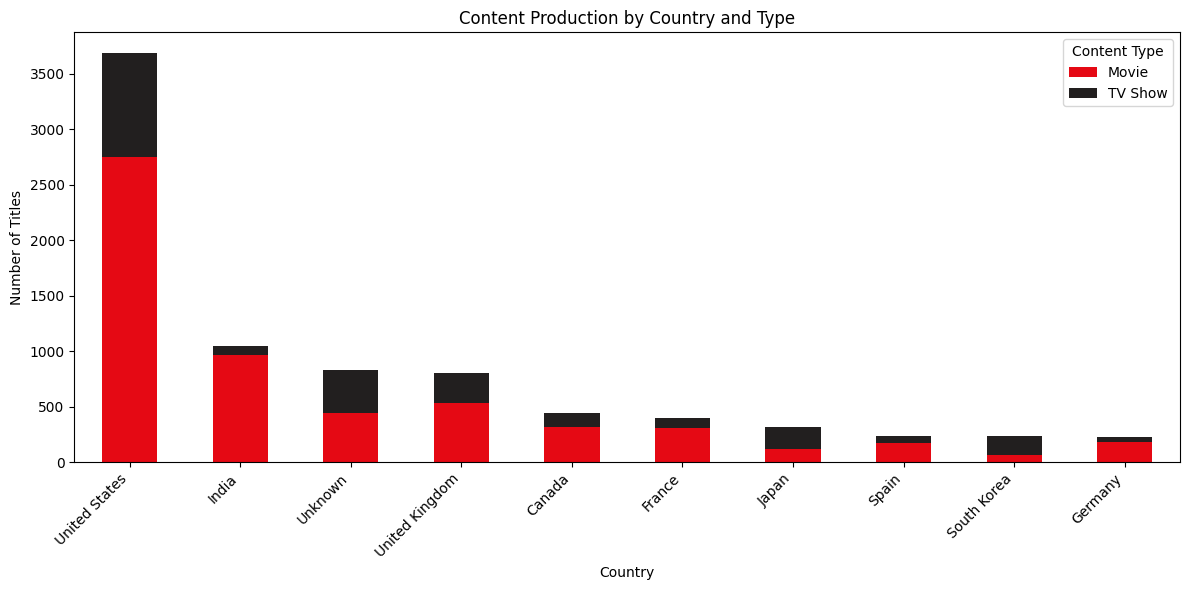

In [55]:
country_type_top.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=['#E50914', '#221f1f']
)

plt.title('Content Production by Country and Type')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Content Type')

plt.tight_layout()
plt.show()


## 6. Content Ratings by Type

In [56]:
rating_type = pd.crosstab(
    df['rating'],
    df['type']
)

rating_type


type,Movie,TV Show
rating,,
66 min,1,0
74 min,1,0
84 min,1,0
G,41,0
NC-17,3,0
NR,75,5
PG,287,0
PG-13,490,0
R,797,2


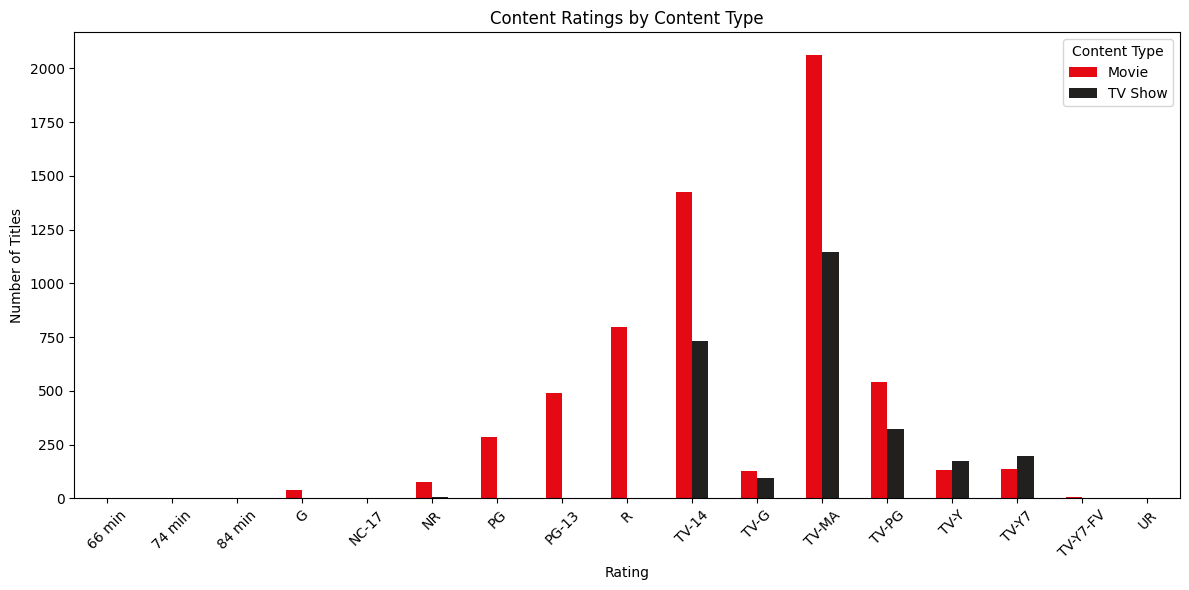

In [57]:
rating_type.plot(
    kind='bar',
    figsize=(12, 6),
    color=['#E50914', '#221f1f']
)

plt.title('Content Ratings by Content Type')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Content Type')

plt.tight_layout()
plt.show()


## 7. Release Years With the Highest Concentration

In [58]:
release_year_count = (
    df['release_year']
    .value_counts()
    .sort_values(ascending=False)
)

release_year_count.head(10)


,count
release_year,
2018,1147
2017,1032
2019,1030
2020,953
2016,902
2021,592
2015,560
2014,352
2013,288


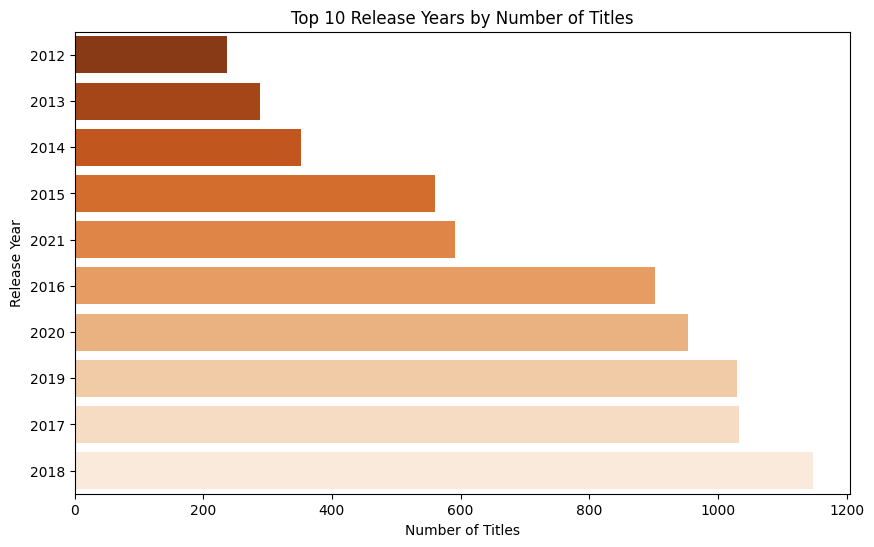

In [59]:
top_years = release_year_count.head(10).sort_values()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_years.values,
    y=top_years.index.astype(str),
    hue=top_years.index.astype(str),
    palette='Oranges_r',
    legend=False
)

plt.title('Top 10 Release Years by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Release Year')

plt.show()


## 8. Typical Movie Duration

In [60]:
movie_duration = df.loc[
    df['type'] == 'Movie',
    'duration_minutes'
].dropna()

movie_duration.describe()


,duration_minutes
count,6128.000000
mean,99.577187
std,28.290593
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


In [61]:
movie_duration.mean()


np.float64(99.57718668407311)

In [62]:
movie_duration.median()


98.0

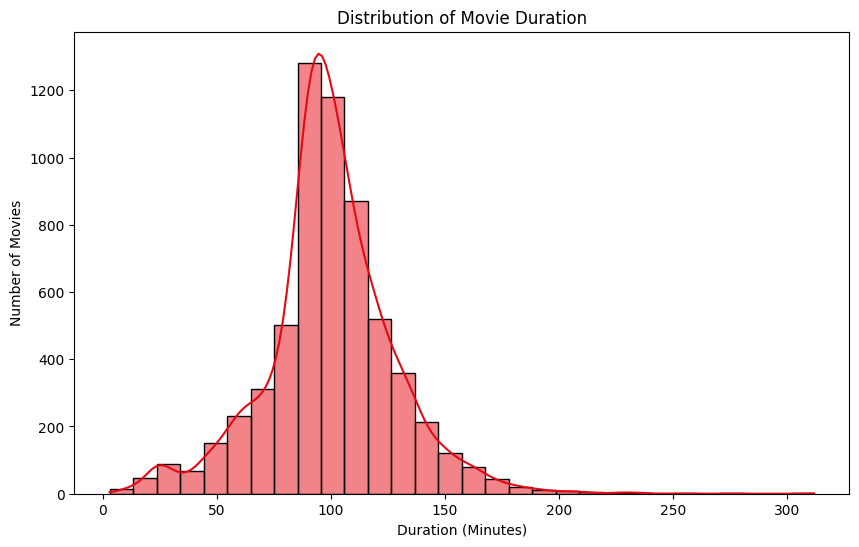

In [63]:
plt.figure(figsize=(10, 6))

sns.histplot(
    movie_duration,
    bins=30,
    kde=True,
    color='#E50914'
)

plt.title('Distribution of Movie Duration')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')

plt.show()


## Business Insights

- Movies dominate Netflix's content library compared with TV Shows.
- Netflix's catalog has a higher concentration of titles from recent release years.
- A few genres, such as Dramas, Comedies, and International content, make up a large portion of the library.
- Some countries contribute content across a wider range of genres, showing greater genre diversity.
- Content contribution by country varies between Movies and TV Shows.
- A few content ratings account for a significant share of Netflix's catalog.
- Recent release years have the highest concentration of titles.
- Most Netflix Movies fall within a common duration range, with some shorter and longer outliers.

## Recommendations

- Maintain a balanced mix of Movies and TV Shows based on content trends.
- Continue investing in popular genres while exploring underrepresented genres.
- Expand content partnerships in countries with high genre diversity.
- Develop country-specific content strategies based on Movie and TV Show contributions.
- Maintain a diverse rating portfolio to serve different audience segments.
- Continue building a strong pipeline of recent and relevant content.
- Monitor movie duration trends when evaluating future content acquisitions.

# Dashboard

In [67]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go


In [65]:
total_titles = len(df)
total_movies = (df['type'] == 'Movie').sum()
total_tv = (df['type'] == 'TV Show').sum()

print("Total Titles:", total_titles)
print("Total Movies:", total_movies)
print("Total TV Shows:", total_tv)

Total Titles: 8807
Total Movies: 6131
Total TV Shows: 2676


## Movies vs TV Shows

In [68]:
content_type = df['type'].value_counts().reset_index()
content_type.columns = ['type', 'count']

fig = px.pie(
    content_type,
    names='type',
    values='count',
    hole=0.4,
    title='Netflix Content Composition',
    color_discrete_sequence=['#E50914', '#221F1F']
)

fig.show()


## Movies vs TV Shows by Release Year

In [71]:
content_year = (
    df[df['release_year'] >= 2000]
    .groupby(['release_year', 'type'])
    .size()
    .reset_index(name='count')
)

fig = px.line(
    content_year,
    x='release_year',
    y='count',
    color='type',
    markers=True,
    title='Movies vs TV Shows by Release Year'
)

fig.show()


## Netflix Content composition

In [69]:
fig.update_layout(
    template='plotly_white',
    title_font_size=20,
    title_x=0.5
)
